In [1]:
import numpy as np
import pandas as pd

In [2]:
df = pd.read_csv('Social_Network_Ads.csv')

In [3]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [4]:
df = df[['Age', 'EstimatedSalary','Purchased']]

In [5]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [6]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [7]:
x

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [8]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

x_scaled = scaler.fit_transform(x)

In [9]:
x_scaled

array([[-1.78179743, -1.49004624],
       [-0.25358736, -1.46068138],
       [-1.11320552, -0.78528968],
       [-1.01769239, -0.37418169],
       [-1.78179743,  0.18375059],
       [-1.01769239, -0.34481683],
       [-1.01769239,  0.41866944],
       [-0.54012675,  2.35674998],
       [-1.20871865, -1.07893824],
       [-0.25358736, -0.13926283],
       [-1.11320552,  0.30121002],
       [-1.11320552, -0.52100597],
       [-1.6862843 ,  0.47739916],
       [-0.54012675, -1.51941109],
       [-1.87731056,  0.35993973],
       [-0.82666613,  0.30121002],
       [ 0.89257019, -1.3138571 ],
       [ 0.70154394, -1.28449224],
       [ 0.79705706, -1.22576253],
       [ 0.98808332, -1.19639767],
       [ 0.70154394, -1.40195167],
       [ 0.89257019, -0.60910054],
       [ 0.98808332, -0.84401939],
       [ 0.70154394, -1.40195167],
       [ 0.79705706, -1.37258681],
       [ 0.89257019, -1.46068138],
       [ 1.08359645, -1.22576253],
       [ 0.89257019, -1.16703281],
       [-0.82666613,

In [10]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=2)

In [11]:
x_train.shape

(320, 2)

In [12]:
import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

In [13]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

In [15]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 10)                30        
                                                                 
 dense_1 (Dense)             (None, 10)                110       
                                                                 
 dense_2 (Dense)             (None, 1)                 11        
                                                                 
Total params: 151
Trainable params: 151
Non-trainable params: 0
_________________________________________________________________


In [16]:
import time

In [18]:
# Stochastic Gradient descent
model.compile(loss='binary_crossentropy',metrics=['accuracy'])
start = time.time()
history = model.fit(x_train,y_train,epochs=10,batch_size=1)
print(time.time()-start)

Epoch 1/10
320/320 [==============================] - 2s 4ms/step - loss: 148.5775 - accuracy: 0.5375
Epoch 2/10
320/320 [==============================] - 1s 3ms/step - loss: 139.8628 - accuracy: 0.5344
Epoch 3/10
320/320 [==============================] - 1s 3ms/step - loss: 141.2114 - accuracy: 0.5063
Epoch 4/10
320/320 [==============================] - 1s 3ms/step - loss: 135.1838 - accuracy: 0.5188
Epoch 5/10
320/320 [==============================] - 1s 3ms/step - loss: 125.2453 - accuracy: 0.5250
Epoch 6/10
320/320 [==============================] - 1s 3ms/step - loss: 126.9931 - accuracy: 0.5281
Epoch 7/10
320/320 [==============================] - 1s 3ms/step - loss: 126.7768 - accuracy: 0.5000
Epoch 8/10
320/320 [==============================] - 1s 4ms/step - loss: 129.6154 - accuracy: 0.4969
Epoch 9/10
320/320 [==============================] - 1s 4ms/step - loss: 123.5882 - accuracy: 0.5469
Epoch 10/10
320/320 [==============================] - 1s 4ms/step - loss: 121.741

In [19]:
import matplotlib.pyplot as plt

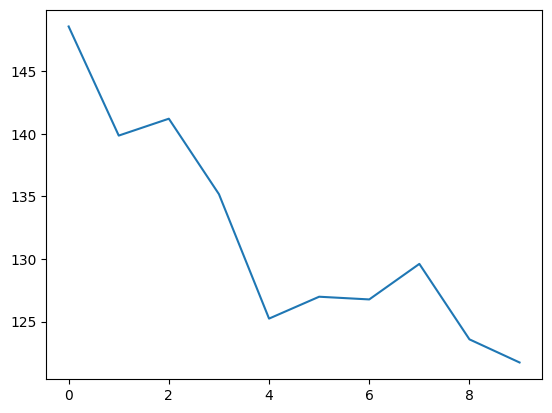

In [20]:
plt.plot(history.history['loss'])